# Edge IIoT - Binary Classification


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import DATASETS

# Seleccionamos el dataset a analizar
dataset_name = "edge_iiot"
config = DATASETS[dataset_name]

print("\n--- Dataset Information ---")
print(f"Name: {dataset_name.upper()}")
print(f"Path: {config['processed_path']}\n")

filename = "ML-EdgeIIoT-dataset"

csv_path = config['processed_path'] / f"{filename}.pkl"
print(f"CSV Path: {csv_path}\n")

print("Loading dataset... (This may take a while)")
df = pd.read_pickle(csv_path)

print(f"\nDataset loaded with shape: {df.shape}")


--- Dataset Information ---
Name: EDGE_IIOT
Path: /home/uo294319/ML-NIDS-IIoT/data/processed/edge_iiot

CSV Path: /home/uo294319/ML-NIDS-IIoT/data/processed/edge_iiot/ML-EdgeIIoT-dataset.pkl

Loading dataset... (This may take a while)

Dataset loaded with shape: (155027, 59)


## 1. Pre-processing

In [3]:
df_naive = df.select_dtypes(include=['number'])

target = 'Attack_label'
X = df_naive.drop(columns=[target])
y = df_naive[target]

Y_str = df['Attack_type'] # Used to stratify later

In [4]:
categorical_cols = X.select_dtypes(include=['str', 'object', 'category']).columns
print(f"Check for categorical columns: {list(categorical_cols)}", "\t(Should only include 'Attack_type')")
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

Check for categorical columns: [] 	(Should only include 'Attack_type')


In [5]:
X.columns

Index(['icmp.seq_le', 'http.content_length', 'http.response', 'http.tls_port',
       'tcp.ack', 'tcp.len', 'tcp.seq', 'udp.stream', 'udp.time_delta',
       'dns.retransmission', 'dns.retransmit_request',
       'dns.retransmit_request_in', 'mqtt.conack.flags',
       'mqtt.conflag.cleansess', 'mqtt.len', 'mqtt.msgtype', 'mbtcp.len',
       'mbtcp.trans_id', 'mbtcp.unit_id', 'frame.time.order',
       'frame.time.delta', 'ip.src_category_Malformed',
       'ip.src_category_Private', 'ip.src_category_Public',
       'ip.src_category_Reserved', 'ip.dst_category_Malformed',
       'ip.dst_category_Private', 'ip.dst_category_Public',
       'ip.dst_category_Reserved', 'arp.opcode_request', 'arp.opcode_reply',
       'http.request.method_get', 'http.request.method_post',
       'http.request.method_options', 'http.request.method_trace',
       'tcp.nullchecksum', 'tcp.flag.res', 'tcp.flag.ns', 'tcp.flag.cwr',
       'tcp.flag.ece', 'tcp.flag.urg', 'tcp.flag.ack', 'tcp.flag.psh',
       'tc

In [6]:
print(f"\nFinal feature set shape after encoding: {X.shape}")
print(f"NaN values in target variable: {y.isna().sum()}")
print(f"NaN values in features: {X.isna().sum().sum()}")


Final feature set shape after encoding: (155027, 50)
NaN values in target variable: 0
NaN values in features: 0


In [7]:
X_train, X_test, y_train, y_test, Y_str_train, Y_str_test = train_test_split(
    X, y, Y_str, test_size=0.2, random_state=42, stratify=Y_str
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_results = {}

X_train shape: (124021, 50)
X_test shape: (31006, 50)


## 2. Model Tuning: RandomForestClassifier
Train and tune an Random Forest classifier using RandomizedSearchCV.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import time

print("Setting up RandomizedSearchCV for RandomForestClassifier...")

# Define baseline model
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    
)

# Parameter grid to sample from, with brief descriptions for each parameter
param_grid = {
    'n_estimators': [50, 100, 200, 300],         # Number of trees in the forest. More trees reduce variance.
    'max_depth': [None, 10, 20, 30],             # Maximum depth of the trees.
    'min_samples_split': [2, 5, 10],             # Minimum number of samples required to split an internal node.
    'min_samples_leaf': [1, 2, 4],               # Minimum number of samples required to be at a leaf node.
    'max_features': ['sqrt', 'log2', None]       # Number of features to consider when looking for the best split.
}

# Setup randomized search (n_iter=10 means it will randomly try 10 combinations)
rf_random = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_grid, 
    n_iter=10, 
    cv=3, 
    verbose=2, 
    random_state=42, 
    n_jobs=-1,
    scoring='accuracy'
)

start_time = time.time()
print("Starting hyperparameter tuning... (This might take a few minutes)")
rf_random.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

print(f"\nHyperparameter tuning completed in {train_time:.2f} seconds.")
print(f"Best parameters found:\n{rf_random.best_params_}")

# Override rf_clf with the best model found so evaluation continues to work
rf_clf = rf_random.best_estimator_


Setting up RandomizedSearchCV for RandomForestClassifier...
Starting hyperparameter tuning... (This might take a few minutes)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   7.5s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   9.1s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   9.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  10.6s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  11.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=  19.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimat

## 3. Evaluation
Evaluate the model's performance on the test set.

Evaluating model on test data...

--- Overall Metrics ---
Accuracy: 0.998645
ROC AUC Score: 0.999984

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4846
           1       1.00      1.00      1.00     26160

    accuracy                           1.00     31006
   macro avg       1.00      1.00      1.00     31006
weighted avg       1.00      1.00      1.00     31006



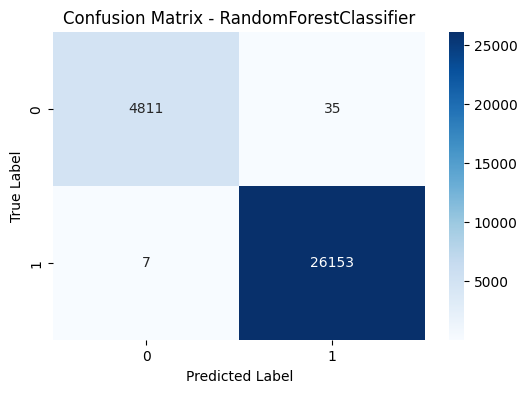

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Evaluating model on test data...")
y_pred = rf_clf.predict(X_test_scaled)
y_prob = rf_clf.predict_proba(X_test_scaled)[:, 1] if hasattr(rf_clf, "predict_proba") else y_pred

print("\n--- Overall Metrics ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.6f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.6f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - RandomForestClassifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


## 4. Feature Importance
Visualize the top features driving the predictions.

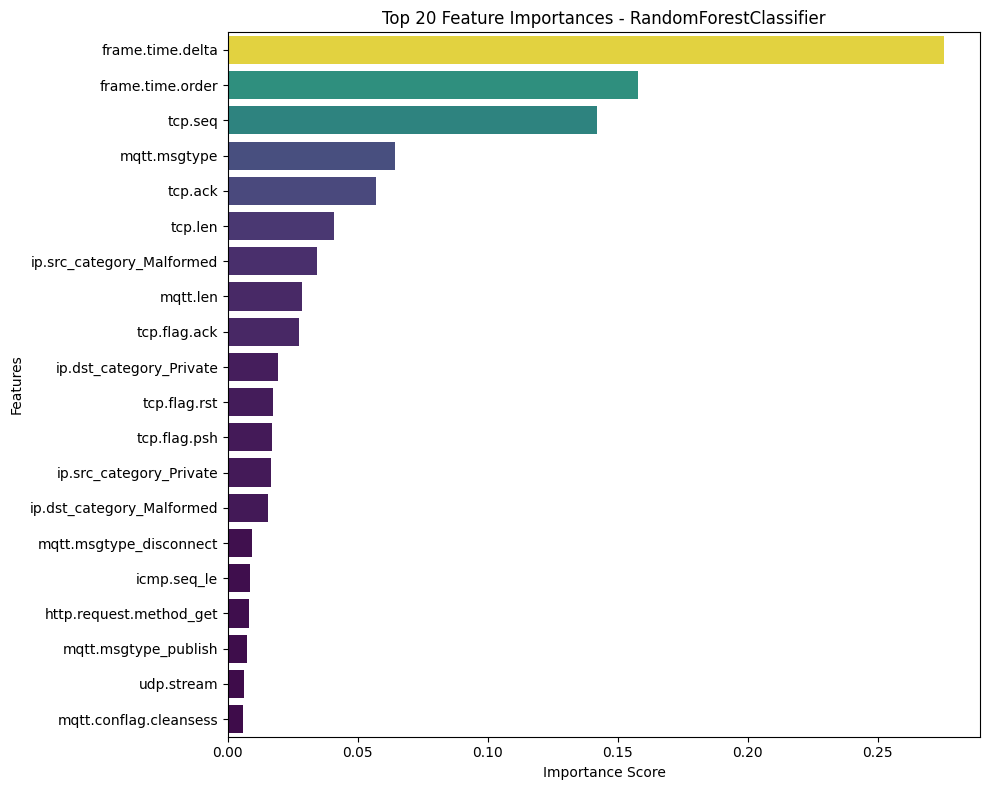

In [10]:
import pandas as pd
import numpy as np

feature_names = X.columns
importances = rf_clf.feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', hue='Importance', data=fi_df, palette='viridis', legend=False)
plt.title('Top 20 Feature Importances - RandomForestClassifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


## 5. Explainable AI (SHAP)
Understand how the model makes its decisions using SHAP (SHapley Additive exPlanations).

In [11]:
import shap
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

shap.initjs() # Initialize JavaScript for interactive visualizations if needed

# 1. Increase sample size: TreeExplainer is fast enough for 5,000+ rows.
n_sample = 5000 
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# 2. Use STRATIFIED sampling to maintain the exact class distribution
if X_test_scaled_df.shape[0] > n_sample:
    X_sample, _, y_sample, _ = train_test_split(
        X_test_scaled_df, 
        y_test, 
        train_size=n_sample, 
        random_state=42, 
        stratify=y_test # Crucial for imbalanced IIoT datasets
    )
else:
    X_sample = X_test_scaled_df.copy()
    y_sample = y_test.copy()

print(f"Extracted {X_sample.shape[0]} stratified observations for SHAP calculation.")
print(f"Class distribution in SHAP sample:\n{y_sample.value_counts(normalize=True).to_string()}")


Extracted 5000 stratified observations for SHAP calculation.
Class distribution in SHAP sample:
Attack_label
1    0.8438
0    0.1562


In [12]:
# Explain the RandomForest model predictions using TreeExplainer
# We pass the best estimator from our RandomizedSearchCV
explainer = shap.TreeExplainer(rf_clf)

# Calculate SHAP values for the stratified sample
# Using the Explanation object (shap_obj) allows for richer plot types
shap_obj = explainer(X_sample)

# Handle the output dimensionality depending on objective function (binary vs multiclass)
if len(shap_obj.shape) == 3:
    plot_obj = shap_obj[:, :, 1] # Extract positive class for binary classification
else:
    plot_obj = shap_obj

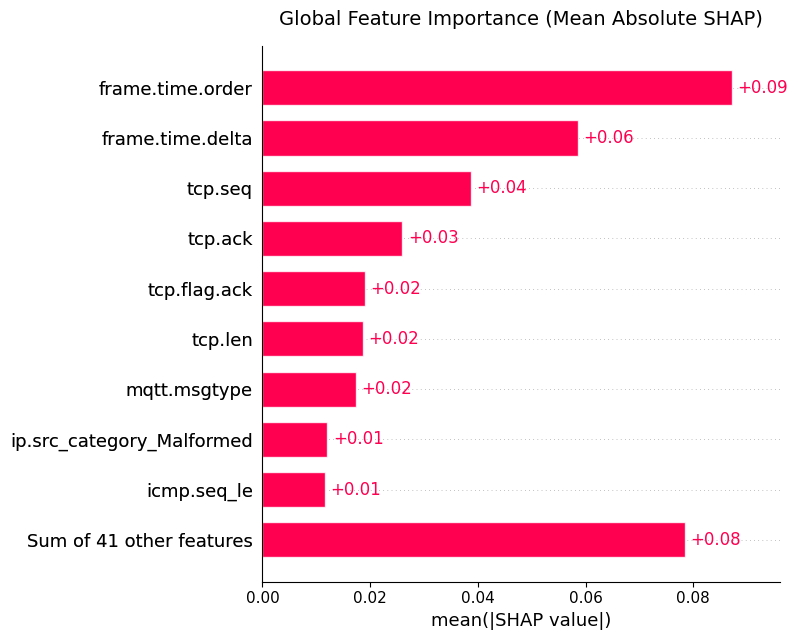

In [13]:
import matplotlib.pyplot as plt

# Plot 1: Global Bar Plot (Mean Absolute SHAP)
plt.figure(figsize=(16, 6))
shap.plots.bar(plot_obj, max_display=10, show=False)
plt.title("Global Feature Importance (Mean Absolute SHAP)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

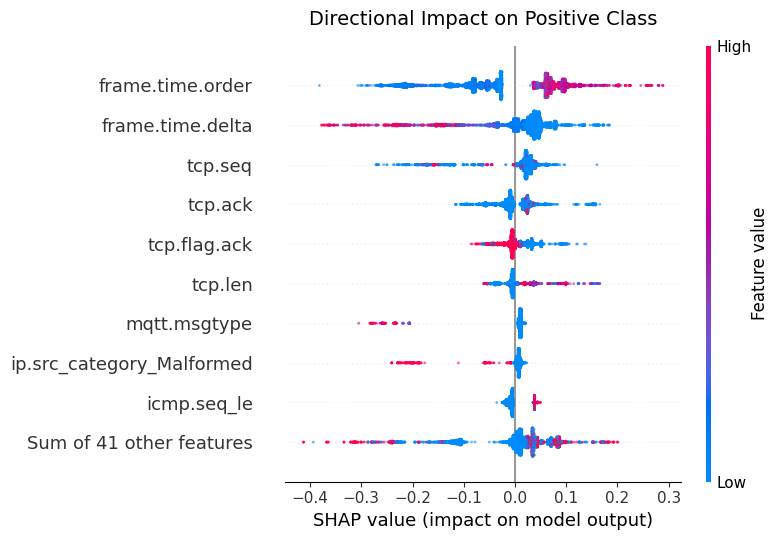

In [14]:
# Plot 2: Beeswarm Plot (Directional Impact)
plt.figure(figsize=(16, 6))
shap.plots.beeswarm(
    plot_obj, 
    max_display=10, 
    s=4,
    alpha=0.6,
    show=False
)
plt.title("Directional Impact on Positive Class", fontsize=14, pad=15)
plt.tight_layout()
plt.show()